In [3]:
# Migration Mode 对比分析: sync vs async vs async_fast
# ==================== 配置 ====================
# 日志目录: project-async-fast_stop_time (包含 stop time 度量的实验)

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

# 设置绘图风格
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 11

# ==================== 统一日志目录配置 ====================
logs_dir = Path("/home/bxb1/vllm_workbench/vllm/new-logs/project-async-fast_7")
LATENCY_METRIC = 'tpot'  # 可选: 'itl' 或 'tpot'
LATENCY_METRIC_OPTIONS = {
    'itl': {
        'metric_key': 'itl_ms',
        'plot_label': 'ITL (ms)',
        'table_label': 'ITL(ms)',
        'default_ymax': 400,
    },
    'tpot': {
        'metric_key': 'tpot_ms',
        'plot_label': 'TPOT (ms)',
        'table_label': 'TPOT(ms)',
        'default_ymax': 400,
    },
}
if LATENCY_METRIC not in LATENCY_METRIC_OPTIONS:
    raise ValueError(f"Unsupported LATENCY_METRIC: {LATENCY_METRIC}")
latency_config = LATENCY_METRIC_OPTIONS[LATENCY_METRIC]
# ==========================================================

def extract_params_from_dirname(dirname):
    """从目录名中提取参数"""
    params = {}
    # 提取 mig_mode
    mig_mode_match = re.search(r'\{mig_mode=([^}]+)\}', dirname)
    if mig_mode_match:
        params['mig_mode'] = mig_mode_match.group(1)
    # 提取 rr
    rr_match = re.search(r'\{rr=([\d.]+)\}', dirname)
    if rr_match:
        params['rr'] = float(rr_match.group(1))
    # 提取 pp
    pp_match = re.search(r'\{pp=([^}]+)\}', dirname)
    if pp_match:
        params['pp'] = pp_match.group(1)
    return params

def extract_request_metrics(request_metrics_csv):
    """从 request_metrics.csv 中提取聚合指标"""
    metrics = {}
    try:
        df = pd.read_csv(request_metrics_csv)
        # TTFT (转换为毫秒)
        metrics['ttft_ms'] = df['ttfts'].mean() * 1000
        # TPOT / Normalized Latency (转换为 ms/tok)
        metrics['normalized_latency_ms_tok'] = df['tpots'].mean() * 1000
        # E2E Latency (秒)
        metrics['e2e_latency_s'] = df['e2els'].mean()
        metrics['num_requests'] = len(df)
    except Exception as e:
        print(f"Error parsing {request_metrics_csv}: {e}")
    return metrics

def extract_benchmark_throughput(benchmark_log):
    """从 benchmark.log 中提取 throughput 和 latency 指标"""
    try:
        with open(benchmark_log, 'r', errors='ignore') as f:
            content = f.read()
        
        metrics = {}
        # Output token throughput (tok/s)
        output_match = re.search(r'Output token throughput \(tok/s\):\s+([\d.]+)', content)
        if output_match:
            metrics['output_throughput_tok_s'] = float(output_match.group(1))
        
        # Total Token throughput (tok/s)
        total_match = re.search(r'Total Token throughput \(tok/s\):\s+([\d.]+)', content)
        if total_match:
            metrics['throughput_tokens_per_s'] = float(total_match.group(1))
        
        # Request throughput (req/s)
        req_match = re.search(r'Request throughput \(req/s\):\s+([\d.]+)', content)
        if req_match:
            metrics['request_throughput_req_s'] = float(req_match.group(1))
        
        # Mean ITL (ms)
        itl_match = re.search(r'Mean ITL \(ms\):\s+([\d.]+)', content)
        if itl_match:
            metrics['itl_ms'] = float(itl_match.group(1))
        
        # Mean TPOT (ms)
        tpot_match = re.search(r'Mean TPOT \(ms\):\s+([\d.]+)', content)
        if tpot_match:
            metrics['tpot_ms'] = float(tpot_match.group(1))
            
        return metrics
    except Exception as e:
        print(f"Error parsing {benchmark_log}: {e}")
    return {}

def extract_migration_time(analysis_file):
    """从 analysis.txt 中提取 migration total time"""
    try:
        with open(analysis_file, 'r', errors='ignore') as f:
            content = f.read()
        
        # 匹配 "[TIMELINE] MIGRATION PROCESS TOTAL TIME" 后的 Event 值
        mig_match = re.search(
            r'\[TIMELINE\] MIGRATION PROCESS TOTAL TIME.*?Event \d+:\s+([\d.]+)(s|ms)',
            content, re.DOTALL
        )
        if mig_match:
            value = float(mig_match.group(1))
            unit = mig_match.group(2)
            if unit == 'ms':
                value = value / 1000  # 转换为秒
            return value
        
        # 如果没有 MIGRATION PROCESS TOTAL TIME，尝试从其他指标估算
        # 对于 sync 模式，可能没有明确的 migration time 记录
        # 使用 Weight Loading 时间作为替代
        wl_match = re.search(
            r'\[Timeline\] After Weight Loading.*?Average:\s+([\d.]+)(s|ms)',
            content, re.DOTALL
        )
        if wl_match:
            value = float(wl_match.group(1))
            unit = wl_match.group(2)
            if unit == 'ms':
                value = value / 1000
            return value
            
    except Exception as e:
        print(f"Error parsing {analysis_file}: {e}")
    return None

def parse_time_value(value_str, unit):
    """将时间值转换为秒"""
    value = float(value_str)
    if unit == 'ms':
        return value / 1000
    elif unit == 'µs':
        return value / 1_000_000
    else:  # 's' or 'seconds'
        return value

def extract_stop_time_components(analysis_file, mig_mode):
    """
    从 analysis.txt 中提取 stop time 的各个组成部分
    
    Stop Time 计算规则:
      - sync/async_fast 模式: 只统计 engine_lock_total (forward_lock 已包含)
      - async 模式: engine_lock_total + forward_lock (add_layers + compact + resize)
    """
    result = {
        'engine_lock_total': 0.0,
        'forward_lock_total': 0.0,
        'forward_lock_add_layers': 0.0,
        'forward_lock_compact': 0.0,
        'forward_lock_resize_shrink': 0.0,
        'forward_lock_resize_grow': 0.0,
    }
    
    try:
        with open(analysis_file, 'r', errors='ignore') as f:
            content = f.read()
        
        # 提取 Engine Lock Total 时间 - 使用模式特定的提取
        if mig_mode == 'sync':
            pattern = r'\[STOP_TIME\] SYNC MODE - FULL BREAKDOWN.*?Event \d+:\s*engine_lock_total=([0-9.]+)(s|ms|µs)'
            match = re.search(pattern, content, re.DOTALL | re.IGNORECASE)
            if match:
                result['engine_lock_total'] = parse_time_value(match.group(1), match.group(2))
        
        elif mig_mode == 'async_fast':
            pattern = r'\[STOP_TIME\] ASYNC-FAST MODE - FULL BREAKDOWN.*?Event \d+:\s*engine_lock_total=([0-9.]+)(s|ms|µs)'
            match = re.search(pattern, content, re.DOTALL | re.IGNORECASE)
            if match:
                result['engine_lock_total'] = parse_time_value(match.group(1), match.group(2))
        
        elif mig_mode == 'async':
            pattern = r'\[STOP_TIME\] ASYNC MODE - FULL BREAKDOWN.*?Event \d+:\s*engine_lock_total=([0-9.]+)(s|ms|µs)'
            match = re.search(pattern, content, re.DOTALL | re.IGNORECASE)
            if match:
                result['engine_lock_total'] = parse_time_value(match.group(1), match.group(2))
        
        # 只对 async 模式统计 forward_lock (其他模式已包含在 engine_lock 中)
        if mig_mode == 'async':
            # Add Layers Forward Lock
            match = re.search(r'\[STOP_TIME\]\[Worker\] Add Layers Forward Lock Hold.*?Average:\s+([\d.]+)(s|ms|µs)', content, re.DOTALL)
            if match:
                result['forward_lock_add_layers'] = parse_time_value(match.group(1), match.group(2))
            
            # Compact Flexi Forward Lock
            match = re.search(r'\[STOP_TIME\]\[Worker\] Compact Flexi Forward Lock Hold.*?Average:\s+([\d.]+)(s|ms|µs)', content, re.DOTALL)
            if match:
                result['forward_lock_compact'] = parse_time_value(match.group(1), match.group(2))
            
            # Resize Shrink Forward Lock
            match = re.search(r'\[STOP_TIME\]\[Worker\] Resize Shrink Forward Lock Hold.*?Average:\s+([\d.]+)(s|ms|µs)', content, re.DOTALL)
            if match:
                result['forward_lock_resize_shrink'] = parse_time_value(match.group(1), match.group(2))
            
            # Resize Grow Forward Lock
            match = re.search(r'\[STOP_TIME\]\[Worker\] Resize Grow Forward Lock Hold.*?Average:\s+([\d.]+)(s|ms|µs)', content, re.DOTALL)
            if match:
                result['forward_lock_resize_grow'] = parse_time_value(match.group(1), match.group(2))
            
            # 计算 Forward Lock Total
            result['forward_lock_total'] = (
                result['forward_lock_add_layers'] +
                result['forward_lock_compact'] +
                result['forward_lock_resize_shrink'] +
                result['forward_lock_resize_grow']
            )
                
    except Exception as e:
        print(f"Error parsing {analysis_file}: {e}")
    
    return result

def calculate_total_stop_time(components, mig_mode):
    """计算总 Stop Time"""
    if mig_mode in ('sync', 'async_fast'):
        return components['engine_lock_total']
    else:  # async
        return components['engine_lock_total'] + components['forward_lock_total']

# ==================== 收集所有数据 ====================
print(f"日志目录: {logs_dir}")
print(f"当前延迟指标: {LATENCY_METRIC} -> {latency_config['metric_key']}")
test_dirs = sorted([d for d in logs_dir.iterdir() if d.is_dir() and d.name.startswith('test-')])
print(f"找到 {len(test_dirs)} 个测试目录")

all_data = []
for test_dir in test_dirs:
    params = extract_params_from_dirname(test_dir.name)
    request_metrics_file = test_dir / "request_metrics.csv"
    benchmark_log_file = test_dir / "benchmark.log"
    analysis_file = test_dir / "analysis.txt"
    
    mig_mode = params.get('mig_mode')
    row = {**params}
    
    # 提取 request metrics
    if request_metrics_file.exists():
        metrics = extract_request_metrics(request_metrics_file)
        row.update(metrics)
    
    # 提取 throughput
    if benchmark_log_file.exists():
        throughput_metrics = extract_benchmark_throughput(benchmark_log_file)
        row.update(throughput_metrics)
    
    # 提取 migration time
    if analysis_file.exists():
        mig_time = extract_migration_time(analysis_file)
        if mig_time is not None:
            row['migration_time_s'] = mig_time
        
        # 提取 stop time
        components = extract_stop_time_components(analysis_file, mig_mode)
        total_stop_time = calculate_total_stop_time(components, mig_mode)
        row['engine_lock_s'] = components['engine_lock_total']
        row['forward_lock_s'] = components['forward_lock_total']
        row['total_stop_time_s'] = total_stop_time
        row['total_stop_time_ms'] = total_stop_time * 1000
    
    all_data.append(row)
    print(
        f"  {params.get('mig_mode')}, rr={params.get('rr')}: "
        f"stop_time={row.get('total_stop_time_ms', 0):.1f}ms, "
        f"ttft={row.get('ttft_ms', 0):.1f}ms, "
        f"itl={row.get('itl_ms', 0):.1f}ms, "
        f"tpot={row.get('tpot_ms', 0):.1f}ms"
    )

df = pd.DataFrame(all_data)
print(f"\n成功处理 {len(df)} 个测试")
print(f"\nDataFrame 列: {df.columns.tolist()}")
print(f"\n数据预览:")
print(df[['mig_mode', 'rr', 'total_stop_time_ms', 'ttft_ms', 'itl_ms', 'tpot_ms', 'throughput_tokens_per_s', 'migration_time_s']].to_string())


日志目录: /home/bxb1/vllm_workbench/vllm/new-logs/project-async-fast_7
当前延迟指标: tpot -> tpot_ms
找到 24 个测试目录
  async_fast, rr=0.5: stop_time=2326.8ms, ttft=345.7ms, itl=96.0ms, tpot=100.2ms
  async_fast, rr=0.5: stop_time=464.5ms, ttft=326.4ms, itl=98.0ms, tpot=100.1ms
  async, rr=0.5: stop_time=10.3ms, ttft=329.4ms, itl=92.1ms, tpot=96.2ms
  sync, rr=0.5: stop_time=4914.8ms, ttft=381.2ms, itl=93.1ms, tpot=97.0ms
  async_fast, rr=1.5: stop_time=2243.1ms, ttft=402.8ms, itl=111.3ms, tpot=145.9ms
  async_fast, rr=1.5: stop_time=589.3ms, ttft=0.0ms, itl=0.0ms, tpot=0.0ms
  async, rr=1.5: stop_time=10.5ms, ttft=365.6ms, itl=112.1ms, tpot=145.1ms
  sync, rr=1.5: stop_time=4551.7ms, ttft=508.5ms, itl=112.4ms, tpot=151.3ms
  async_fast, rr=1.0: stop_time=1839.2ms, ttft=380.1ms, itl=102.4ms, tpot=121.5ms
  async_fast, rr=1.0: stop_time=346.6ms, ttft=344.7ms, itl=101.5ms, tpot=118.2ms
  async, rr=1.0: stop_time=9.8ms, ttft=355.7ms, itl=105.7ms, tpot=120.9ms
  sync, rr=1.0: stop_time=4642.5ms, ttft=424

提取 PipeLive: 6 个数据点
提取 KV Patch Disabled (Async): 6 个数据点
提取 Sync: 6 个数据点
已保存: /home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-migration-mode-stop-time.pdf
已保存: /home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-migration-mode-stop-time.png


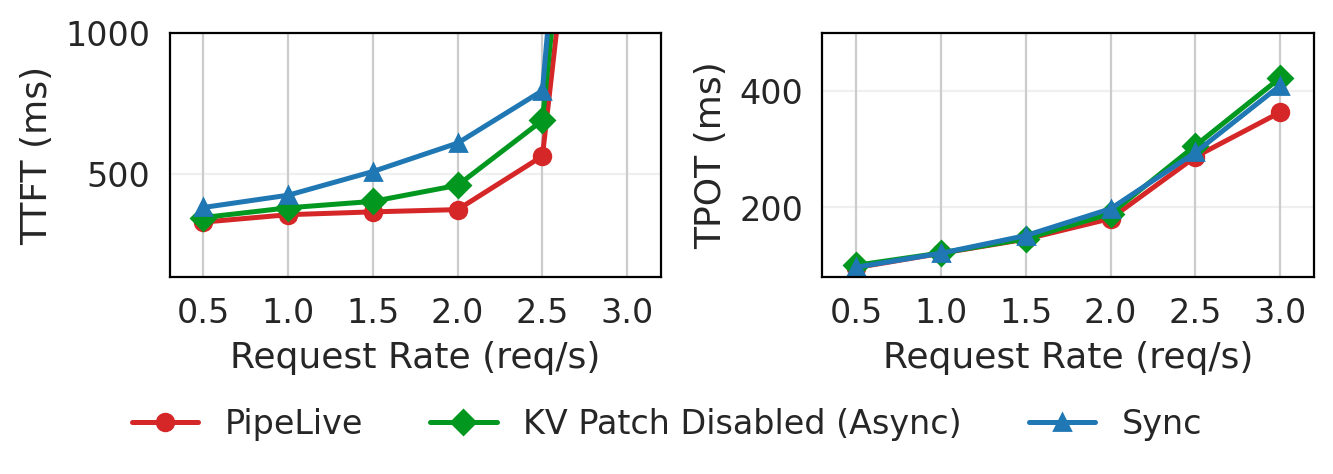


Stop Time 实验数据汇总（当前延迟指标: TPOT(ms)）:
Series                           RR     TTFT(ms)     TPOT(ms)           Throughput(tok/s)    WL       MigMode      MigTime(s)   StopTime(ms)
--------------------------------------------------------------------------------------------------------------------------------------------------------
KV Patch Disabled (Async)        0.5    345.68       100.23             219.12               async    async_fast   6.200        2326.83     
KV Patch Disabled (Async)        1.0    380.05       121.47             390.20               async    async_fast   5.600        1839.18     
KV Patch Disabled (Async)        1.5    402.83       145.95             534.13               async    async_fast   6.200        2243.09     
KV Patch Disabled (Async)        2.0    459.79       188.98             647.10               async    async_fast   6.700        2126.25     
KV Patch Disabled (Async)        2.5    689.58       305.81             747.21               async    asy

In [4]:

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams['figure.dpi'] = 200

# ==================== 字体大小配置 ====================
FONT_SIZE_TICK = 12       # 刻度标签字体大小
FONT_SIZE_LABEL = 13      # 坐标轴标签字体大小
FONT_SIZE_LEGEND = 12     # 图例字体大小
# =====================================================

selected_latency_key = latency_config['metric_key']
selected_latency_label = latency_config['plot_label']
selected_latency_table_label = latency_config['table_label']
selected_latency_ymax = latency_config['default_ymax']

def extract_params_with_wl(dirname):
    params = extract_params_from_dirname(dirname)
    wl_match = re.search(r'\{wl=([^}]+)\}', dirname)
    if wl_match:
        params['wl'] = wl_match.group(1)
    return params

def collect_series_rows(source_dir, mig_mode, wl, series_key, series_label):
    rows = []
    if not source_dir.exists():
        return rows

    for test_dir in sorted([d for d in source_dir.iterdir() if d.is_dir() and d.name.startswith('test-')]):
        params = extract_params_with_wl(test_dir.name)
        # 如果目录名中不含 {wl=...}，则跳过 wl 过滤（兼容旧格式）
        if params.get('mig_mode') != mig_mode:
            continue
        if params.get('wl') is not None and params.get('wl') != wl:
            continue

        row = {**params}
        request_metrics_file = test_dir / "request_metrics.csv"
        benchmark_log_file = test_dir / "benchmark.log"
        analysis_file = test_dir / "analysis.txt"

        if request_metrics_file.exists():
            row.update(extract_request_metrics(request_metrics_file))
        if benchmark_log_file.exists():
            row.update(extract_benchmark_throughput(benchmark_log_file))
        if analysis_file.exists():
            mig_time = extract_migration_time(analysis_file)
            if mig_time is not None:
                row['migration_time_s'] = mig_time

            components = extract_stop_time_components(analysis_file, mig_mode)
            total_stop_time = calculate_total_stop_time(components, mig_mode)
            row['engine_lock_s'] = components['engine_lock_total']
            row['forward_lock_s'] = components['forward_lock_total']
            row['total_stop_time_s'] = total_stop_time
            row['total_stop_time_ms'] = total_stop_time * 1000

        row['series_key'] = series_key
        row['series_label'] = series_label
        rows.append(row)

    return rows

series_specs = [
    {
        'source_dir': logs_dir,
        'mig_mode': 'async',
        'wl': 'sync',
        'series_key': 'pipelive',
        'series_label': 'PipeLive',
    },
    {
        'source_dir': logs_dir,
        'mig_mode': 'async_fast',
        'wl': 'async',
        'series_key': 'kv_patch_disabled_async',
        'series_label': 'KV Patch Disabled (Async)',
    },
    {
        'source_dir': logs_dir,
        'mig_mode': 'sync',
        'wl': 'sync',
        'series_key': 'sync_mig_mode',
        'series_label': 'Sync',
    },
]

plot_rows = []
for spec in series_specs:
    rows = collect_series_rows(
        spec['source_dir'],
        spec['mig_mode'],
        spec['wl'],
        spec['series_key'],
        spec['series_label'],
    )
    plot_rows.extend(rows)
    print(f"提取 {spec['series_label']}: {len(rows)} 个数据点")

plot_df = pd.DataFrame(plot_rows)
plot_df = plot_df.dropna(subset=['rr'])

if plot_df.empty:
    raise ValueError('未解析到可绘图的数据，请检查日志目录和筛选条件。')

rr_values = sorted(plot_df['rr'].unique())
series_order = ['pipelive', 'kv_patch_disabled_async', 'sync_mig_mode']

# 要绘制的指标
metrics_to_plot = [
    ('ttft_ms', 'TTFT (ms)', 1000, True),
    (selected_latency_key, selected_latency_label, 500, False),
]

mode_labels = {
    'pipelive': 'PipeLive',
    'kv_patch_disabled_async': 'KV Patch Disabled (Async)',
    'sync_mig_mode': 'Sync',
}
colors = {
    'pipelive': '#D62728',
    'kv_patch_disabled_async': "#029820",
    'sync_mig_mode': '#1F77B4',
}
markers = {
    'pipelive': 'o',
    'kv_patch_disabled_async': 'D',
    'sync_mig_mode': '^',
}
linestyles = {
    'pipelive': '-',
    'kv_patch_disabled_async': '-',
    'sync_mig_mode': '-',
}

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(6.8, 2.2))

for col_idx, (metric_key, metric_label, y_max, use_log_scale) in enumerate(metrics_to_plot):
    ax = axes[col_idx]

    for series_key in series_order:
        series_df = (
            plot_df[plot_df['series_key'] == series_key]
            .sort_values('rr')
            .dropna(subset=[metric_key])
        )
        if series_df.empty:
            continue

        x_vals = series_df['rr'].tolist()
        y_vals = series_df[metric_key].tolist()
        x_pos = [rr_values.index(rr) for rr in x_vals]
        ax.plot(
            x_pos,
            y_vals,
            color=colors[series_key],
            marker=markers[series_key],
            linestyle=linestyles[series_key],
            linewidth=1.8,
            markersize=6,
            label=mode_labels[series_key],
        )

    n_x = len(rr_values)
    ax.set_xticks(range(n_x))
    ax.set_xticklabels([str(r) for r in rr_values], fontsize=FONT_SIZE_TICK)
    ax.set_xlabel('Request Rate (req/s)', fontsize=FONT_SIZE_LABEL)
    ax.set_ylabel(metric_label, fontsize=FONT_SIZE_LABEL)
    ax.tick_params(axis='y', labelsize=FONT_SIZE_TICK)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xlim(-0.4, n_x - 1 + 0.4)

    ax.set_ylim(top=y_max)

    # 添加子图外框
    for spine in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(0.8)
        ax.spines[spine].set_color('black')

# 共享图例放底部，全部横排
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1),
           ncol=3, fontsize=FONT_SIZE_LEGEND, frameon=False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.34)

out_pdf = '/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-migration-mode-stop-time.pdf'
out_png = '/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-migration-mode-stop-time.png'
plt.savefig(out_pdf, format='pdf', bbox_inches='tight')
plt.savefig(out_png, dpi=300, bbox_inches='tight')
print(f"已保存: {out_pdf}")
print(f"已保存: {out_png}")
plt.show()

# 打印数据表格
print("\n" + "="*120)
print(f"Stop Time 实验数据汇总（当前延迟指标: {selected_latency_table_label}）:")
print("="*120)
print(f"{'Series':<32} {'RR':<6} {'TTFT(ms)':<12} {selected_latency_table_label:<18} {'Throughput(tok/s)':<20} {'WL':<8} {'MigMode':<12} {'MigTime(s)':<12} {'StopTime(ms)':<12}")
print("-"*152)
for _, row in plot_df.sort_values(['series_key', 'rr']).iterrows():
    series_label = row.get('series_label', row.get('series_key', row.get('mig_mode', 'unknown')))
    rr = row['rr']
    ttft = row.get('ttft_ms', 0)
    latency_value = row.get(selected_latency_key, 0)
    throughput = row.get('throughput_tokens_per_s', 0)
    wl = row.get('wl', 'N/A')
    mig_mode = row.get('mig_mode', 'unknown')
    mig_time = row.get('migration_time_s', 0)
    stop_time = row.get('total_stop_time_ms', 0)
    print(f"{series_label:<32} {rr:<6.1f} {ttft:<12.2f} {latency_value:<18.2f} {throughput:<20.2f} {wl:<8} {mig_mode:<12} {mig_time:<12.3f} {stop_time:<12.2f}")

# ==================== PipeLive 性能提升分析 ====================
print("\n" + "="*120)
print("PipeLive 相比 Baseline 的性能提升（延迟类指标: 负值=PipeLive更好 | Throughput: 正值=PipeLive更好）")
print("="*120)

def fmt_delta(val_fs, val_base, higher_is_better=False):
    """格式化性能对比：返回变化百分比字符串"""
    if val_base == 0 or pd.isna(val_base) or pd.isna(val_fs):
        return "N/A"
    delta = (val_fs - val_base) / val_base * 100
    return f"{delta:+.1f}%"

fs_df = plot_df[plot_df['series_key'] == 'pipelive'].set_index('rr')
baselines = [
    ('sync_mig_mode', 'vs Sync'),
    ('kv_patch_disabled_async', 'vs KV Patch Disabled'),
]

metric_cols = [
    (selected_latency_key, selected_latency_table_label, False),
    ('ttft_ms',             'TTFT(ms)',                  False),
    ('throughput_tokens_per_s', 'Throughput',            True),
    ('total_stop_time_ms',  'StopTime(ms)',              False),
]

for base_key, base_label in baselines:
    base_df = plot_df[plot_df['series_key'] == base_key].set_index('rr')
    common_rrs = sorted(set(fs_df.index) & set(base_df.index))
    if not common_rrs:
        print(f"\n  {base_label}: 没有共同 RR 数据点")
        continue

    header_parts = f"{'RR':<6}"
    for _, col_label, _ in metric_cols:
        header_parts += f" {col_label:<18}"
    print(f"\n  {base_label}:")
    print(f"  {'RR':<6}" + "".join(f" {col_label:<18}" for _, col_label, _ in metric_cols))
    print("  " + "-"*80)
    for rr_val in common_rrs:
        row_parts = f"  {rr_val:<6.1f}"
        for col_key, col_label, higher_better in metric_cols:
            fs_val  = fs_df.loc[rr_val, col_key]  if col_key in fs_df.columns  else float('nan')
            base_val = base_df.loc[rr_val, col_key] if col_key in base_df.columns else float('nan')
            delta_str = fmt_delta(fs_val, base_val, higher_is_better=higher_better)
            row_parts += f" {delta_str:<18}"
        print(row_parts)


In [5]:
# ==================== Migration 时间窗指标（基于现有数据） ====================
# 说明:
## 1) 这里使用 server_raw.log.repN 中的 "Start migrating to new configuration" 作为 migration 开始时刻
## 2) 使用 request_metrics.csv.repN 中每个 request 的开始时间戳进行对齐
## 3) 现有数据只能稳定重算: Request Throughput / TTFT / TPOT / E2EL
## 4) ITL / Normalized Latency / token throughput 由于缺少 request 级原始字段，当前无法从该目录精确重算

from datetime import datetime

WINDOW_SECONDS = 10.0  # 可修改: migration 前后各多少秒
WINDOW_YEAR = 2026

MIGRATION_START_PATTERN = re.compile(
    r'INFO\s+(\d{2}-\d{2})\s+(\d{2}:\d{2}:\d{2}).*?Start migrating to new configuration'
 )

def extract_window_params(dirname):
    params = extract_params_with_wl(dirname)
    tgt_pp_match = re.search(r'\{tgt_pp=([^}]+)\}', dirname)
    if tgt_pp_match:
        params['tgt_pp'] = tgt_pp_match.group(1)
    else:
        params['tgt_pp'] = 'unknown'
    return params

def parse_migration_start_ts(server_log_file, year=WINDOW_YEAR):
    """从 server_raw.log.repN 中提取 migration 开始时间戳（Unix seconds）"""
    if not server_log_file.exists():
        return None
    with open(server_log_file, 'r', errors='ignore') as f:
        for line in f:
            match = MIGRATION_START_PATTERN.search(line)
            if match:
                month_day = match.group(1)
                hhmmss = match.group(2)
                dt = datetime.strptime(
                    f"{year}-{month_day} {hhmmss}",
                    "%Y-%m-%d %H:%M:%S",
                )
                return dt.timestamp()
    return None

def summarize_request_window(window_df, window_seconds):
    """基于现有 request_metrics.csv 可重算的窗口指标"""
    if window_df.empty:
        return {
            'request_count': 0,
            'request_throughput_req_s': 0.0,
            'ttft_ms': np.nan,
            'tpot_ms': np.nan,
            'e2el_ms': np.nan,
        }

    duration_s = max(window_seconds, 1e-9)
    return {
        'request_count': len(window_df),
        'request_throughput_req_s': len(window_df) / duration_s,
        'ttft_ms': window_df['ttfts'].mean() * 1000,
        'tpot_ms': window_df['tpots'].mean() * 1000,
        'e2el_ms': window_df['e2els'].mean() * 1000,
    }

def collect_migration_window_metrics(log_root, window_seconds=WINDOW_SECONDS):
    """
    对 log_root 下所有 test-* 目录计算 migration 前/中/后的窗口指标。
    窗口定义:
      - pre      : [migration_start - X, migration_start)
      - centered : [migration_start - X, migration_start + X]
      - post     : [migration_start, migration_start + X]
    """
    log_root = Path(log_root)
    results = []

    for test_dir in sorted(d for d in log_root.iterdir() if d.is_dir() and d.name.startswith('test-')):
        params = extract_window_params(test_dir.name)

        for rep in range(1, 6):
            request_metrics_file = test_dir / f"request_metrics.csv.rep{rep}"
            server_raw_log_file = test_dir / f"server_raw.log.rep{rep}"
            if not request_metrics_file.exists() or not server_raw_log_file.exists():
                continue

            migration_start_ts = parse_migration_start_ts(server_raw_log_file)
            if migration_start_ts is None:
                continue

            req_df = pd.read_csv(request_metrics_file)
            if req_df.empty or 'timestamp' not in req_df.columns:
                continue

            windows = {
                'pre': req_df[
                    (req_df['timestamp'] >= migration_start_ts - window_seconds)
                    & (req_df['timestamp'] < migration_start_ts)
                ],
                'centered': req_df[
                    (req_df['timestamp'] >= migration_start_ts - window_seconds)
                    & (req_df['timestamp'] <= migration_start_ts + window_seconds)
                ],
                'post': req_df[
                    (req_df['timestamp'] >= migration_start_ts)
                    & (req_df['timestamp'] <= migration_start_ts + window_seconds)
                ],
            }

            for window_name, window_df in windows.items():
                row = {
                    **params,
                    'repetition': rep,
                    'window_name': window_name,
                    'window_seconds': window_seconds,
                    'migration_start_ts': migration_start_ts,
                }
                duration = 2 * window_seconds if window_name == 'centered' else window_seconds
                row.update(summarize_request_window(window_df, duration))
                results.append(row)

    if not results:
        return pd.DataFrame()

    return pd.DataFrame(results)

window_df = collect_migration_window_metrics(logs_dir, window_seconds=WINDOW_SECONDS)
if window_df.empty:
    raise ValueError(f"未能在 {logs_dir} 中解析到 migration 时间窗数据")

window_summary_df = (
    window_df
    .groupby(['mig_mode', 'wl', 'rr', 'tgt_pp', 'window_name', 'window_seconds'], dropna=False)
    .agg(
        repetitions=('repetition', 'count'),
        avg_request_count=('request_count', 'mean'),
        avg_request_throughput_req_s=('request_throughput_req_s', 'mean'),
        avg_ttft_ms=('ttft_ms', 'mean'),
        avg_tpot_ms=('tpot_ms', 'mean'),
        avg_e2el_ms=('e2el_ms', 'mean'),
        std_ttft_ms=('ttft_ms', lambda s: np.nanstd(s.to_numpy(), ddof=0)),
        std_tpot_ms=('tpot_ms', lambda s: np.nanstd(s.to_numpy(), ddof=0)),
        std_e2el_ms=('e2el_ms', lambda s: np.nanstd(s.to_numpy(), ddof=0)),
    )
    .reset_index()
    .sort_values(['rr', 'mig_mode', 'wl', 'window_name'])
)

print(f"logs_dir = {logs_dir}")
print(f"migration 时间窗 = ±{WINDOW_SECONDS:.1f}s（并同时输出 pre/post 子窗口）")
print("注意: 现有数据无法精确重算 ITL / Normalized Latency / token throughput")
print("\n每个 repetition 的窗口结果预览:")
display_cols = [
    'mig_mode', 'wl', 'rr', 'tgt_pp', 'repetition', 'window_name',
    'request_count', 'request_throughput_req_s', 'ttft_ms', 'tpot_ms', 'e2el_ms',
]
print(window_df[display_cols].head(18).to_string(index=False, float_format=lambda x: f"{x:.2f}"))

print("\n聚合后的窗口结果:")
summary_cols = [
    'mig_mode', 'wl', 'rr', 'tgt_pp', 'window_name', 'repetitions',
    'avg_request_count', 'avg_request_throughput_req_s',
    'avg_ttft_ms', 'avg_tpot_ms', 'avg_e2el_ms',
]
print(window_summary_df[summary_cols].to_string(index=False, float_format=lambda x: f"{x:.2f}"))

logs_dir = /home/bxb1/vllm_workbench/vllm/new-logs/project-async-fast_7
migration 时间窗 = ±10.0s（并同时输出 pre/post 子窗口）
注意: 现有数据无法精确重算 ITL / Normalized Latency / token throughput

每个 repetition 的窗口结果预览:
  mig_mode    wl   rr tgt_pp  repetition window_name  request_count  request_throughput_req_s  ttft_ms  tpot_ms  e2el_ms
async_fast async 0.50  56-24           1         pre              5                      0.50   423.68   102.02  1954.01
async_fast async 0.50  56-24           1    centered             11                      0.55   764.24   132.11 10180.25
async_fast async 0.50  56-24           1        post              6                      0.60  1048.03   157.18 17035.45
async_fast async 0.50  56-24           2         pre              5                      0.50   423.16   101.88  1951.31
async_fast async 0.50  56-24           2    centered             11                      0.55   827.17   136.53 10266.22
async_fast async 0.50  56-24           2        post              6         

已保存: /home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-migration-centered10s-window-ttft-tpot.pdf
已保存: /home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-migration-centered10s-window-ttft-tpot.png


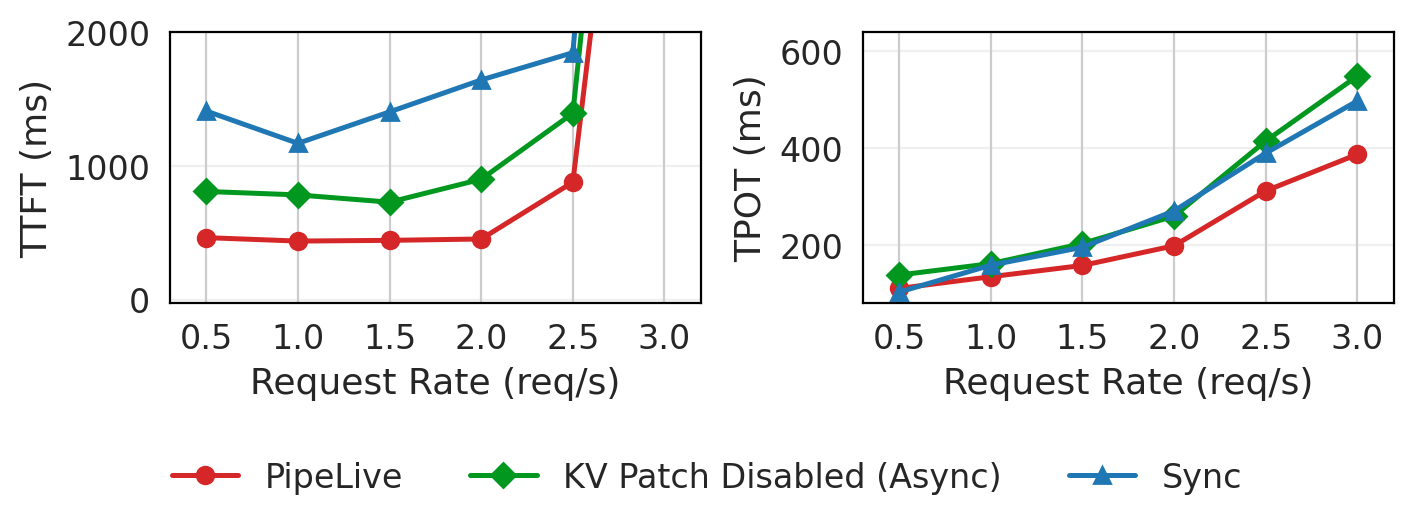


Migration 前后各 10s 窗口内 TTFT/TPOT 对比:
Series                           RR     TTFT(ms)     TPOT(ms)     ReqThru(req/s)   AvgReqCount  Reps  
------------------------------------------------------------------------------------------------------------------------
KV Patch Disabled (Async)        0.5    808.01       137.58       0.56             11.20        5     
KV Patch Disabled (Async)        1.0    782.16       161.10       1.05             21.00        5     
KV Patch Disabled (Async)        1.5    727.97       202.60       1.56             31.20        5     
KV Patch Disabled (Async)        2.0    899.45       259.36       2.01             40.20        5     
KV Patch Disabled (Async)        2.5    1393.05      414.37       2.51             50.20        5     
KV Patch Disabled (Async)        3.0    7929.39      548.57       3.02             60.40        5     
PipeLive                         0.5    462.53       109.92       0.55             11.00        5     
PipeLive          

In [6]:
# ==================== Migration 前后 10s 窗口：TTFT / TPOT 对比 ====================
# 参考上面的折线图风格，使用 migration 开始前后各 10 秒的 centered window

CENTER_WINDOW_SECONDS = 10.0
center_window_df = collect_migration_window_metrics(logs_dir, window_seconds=CENTER_WINDOW_SECONDS)
if center_window_df.empty:
    raise ValueError(f"未能在 {logs_dir} 中解析到 migration centered-window 数据")

center_summary_df = (
    center_window_df[center_window_df['window_name'] == 'centered']
    .groupby(['mig_mode', 'wl', 'rr', 'tgt_pp'], dropna=False)
    .agg(
        repetitions=('repetition', 'count'),
        avg_request_count=('request_count', 'mean'),
        avg_request_throughput_req_s=('request_throughput_req_s', 'mean'),
        avg_ttft_ms=('ttft_ms', 'mean'),
        avg_tpot_ms=('tpot_ms', 'mean'),
        std_ttft_ms=('ttft_ms', lambda s: np.nanstd(s.to_numpy(), ddof=0)),
        std_tpot_ms=('tpot_ms', lambda s: np.nanstd(s.to_numpy(), ddof=0)),
    )
    .reset_index()
    .sort_values(['rr', 'mig_mode', 'wl'])
)

center_series_specs = [
    {
        'mig_mode': 'async',
        'wl': 'sync',
        'series_key': 'pipelive',
        'series_label': 'PipeLive',
    },
    {
        'mig_mode': 'async_fast',
        'wl': 'async',
        'series_key': 'kv_patch_disabled_async',
        'series_label': 'KV Patch Disabled (Async)',
    },
    {
        'mig_mode': 'sync',
        'wl': 'sync',
        'series_key': 'sync_mig_mode',
        'series_label': 'Sync',
    },
]

center_plot_rows = []
for spec in center_series_specs:
    subset = center_summary_df[
        (center_summary_df['mig_mode'] == spec['mig_mode'])
        & (center_summary_df['wl'] == spec['wl'])
    ].copy()
    subset['series_key'] = spec['series_key']
    subset['series_label'] = spec['series_label']
    center_plot_rows.append(subset)

center_plot_df = pd.concat(center_plot_rows, ignore_index=True)
rr_values_center = sorted(center_plot_df['rr'].dropna().unique())
series_order_center = ['pipelive', 'kv_patch_disabled_async', 'sync_mig_mode']

metrics_to_plot_center = [
    ('avg_ttft_ms', 'TTFT (ms)', 2000),
    ('avg_tpot_ms', 'TPOT (ms)', None),
]

mode_labels_center = {
    'pipelive': 'PipeLive',
    'kv_patch_disabled_async': 'KV Patch Disabled (Async)',
    'sync_mig_mode': 'Sync',
}

colors_center = {
    'pipelive': '#D62728',
    'kv_patch_disabled_async': '#029820',
    'sync_mig_mode': '#1F77B4',
}

markers_center = {
    'pipelive': 'o',
    'kv_patch_disabled_async': 'D',
    'sync_mig_mode': '^',
}

linestyles_center = {
    'pipelive': '-',
    'kv_patch_disabled_async': '-',
    'sync_mig_mode': '-',
}

fig, axes = plt.subplots(1, len(metrics_to_plot_center), figsize=(7.2, 2.4))

for col_idx, (metric_key, metric_label, y_max) in enumerate(metrics_to_plot_center):
    ax = axes[col_idx]
    for series_key in series_order_center:
        series_df = (
            center_plot_df[center_plot_df['series_key'] == series_key]
            .sort_values('rr')
            .dropna(subset=[metric_key])
        )
        if series_df.empty:
            continue

        x_vals = series_df['rr'].tolist()
        y_vals = series_df[metric_key].tolist()
        x_pos = [rr_values_center.index(rr) for rr in x_vals]
        ax.plot(
            x_pos,
            y_vals,
            color=colors_center[series_key],
            marker=markers_center[series_key],
            linestyle=linestyles_center[series_key],
            linewidth=1.8,
            markersize=6,
            label=mode_labels_center[series_key],
        )

    ax.set_xticks(range(len(rr_values_center)))
    ax.set_xticklabels([str(r) for r in rr_values_center], fontsize=FONT_SIZE_TICK)
    ax.set_xlabel('Request Rate (req/s)', fontsize=FONT_SIZE_LABEL)
    ax.set_ylabel(metric_label, fontsize=FONT_SIZE_LABEL)
    ax.tick_params(axis='y', labelsize=FONT_SIZE_TICK)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xlim(-0.4, len(rr_values_center) - 1 + 0.4)

    if y_max is not None:
        ax.set_ylim(top=y_max)
    else:
        ax.set_ylim(top=ax.get_ylim()[1] * 1.12)

    for spine in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(0.8)
        ax.spines[spine].set_color('black')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.12),
           ncol=3, fontsize=FONT_SIZE_LEGEND, frameon=False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.34)

out_pdf = '/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-migration-centered10s-window-ttft-tpot.pdf'
out_png = '/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-migration-centered10s-window-ttft-tpot.png'
plt.savefig(out_pdf, format='pdf', bbox_inches='tight')
plt.savefig(out_png, dpi=300, bbox_inches='tight')
print(f"已保存: {out_pdf}")
print(f"已保存: {out_png}")
plt.show()

print(f"\nMigration 前后各 {CENTER_WINDOW_SECONDS:.0f}s 窗口内 TTFT/TPOT 对比:")
print('=' * 120)
print(f"{'Series':<32} {'RR':<6} {'TTFT(ms)':<12} {'TPOT(ms)':<12} {'ReqThru(req/s)':<16} {'AvgReqCount':<12} {'Reps':<6}")
print('-' * 120)
for _, row in center_plot_df.sort_values(['series_key', 'rr']).iterrows():
    print(
        f"{row['series_label']:<32} {row['rr']:<6.1f} {row['avg_ttft_ms']:<12.2f} "
        f"{row['avg_tpot_ms']:<12.2f} {row['avg_request_throughput_req_s']:<16.2f} "
        f"{row['avg_request_count']:<12.2f} {row['repetitions']:<6d}"
    )

print("\n" + "=" * 120)
print("PipeLive 相比两个 baseline 的差距范围")
print("=" * 120)

def summarize_gap_range(plot_df, pipelive_key='pipelive', baselines=None):
    if baselines is None:
        baselines = [
            ('sync_mig_mode', 'vs Sync'),
            ('kv_patch_disabled_async', 'vs KV Patch Disabled (Async)'),
        ]

    pipelive_df = plot_df[plot_df['series_key'] == pipelive_key].set_index('rr')
    metric_specs = [
        ('avg_ttft_ms', 'TTFT(ms)'),
        ('avg_tpot_ms', 'TPOT(ms)'),
    ]

    for baseline_key, baseline_label in baselines:
        baseline_df = plot_df[plot_df['series_key'] == baseline_key].set_index('rr')
        common_rrs = sorted(set(pipelive_df.index) & set(baseline_df.index))
        if not common_rrs:
            print(f"\n{baseline_label}: 没有共同 RR 数据点")
            continue

        print(f"\n{baseline_label}:")
        for metric_key, metric_label in metric_specs:
            abs_gaps = []
            pct_gaps = []
            for rr in common_rrs:
                pipelive_val = pipelive_df.loc[rr, metric_key]
                baseline_val = baseline_df.loc[rr, metric_key]
                abs_gap = pipelive_val - baseline_val
                pct_gap = abs_gap / baseline_val * 100 if baseline_val != 0 else np.nan
                abs_gaps.append((rr, abs_gap))
                pct_gaps.append((rr, pct_gap))

            abs_gap_values = [v for _, v in abs_gaps]
            pct_gap_values = [v for _, v in pct_gaps if not np.isnan(v)]

            min_abs_rr, min_abs_gap = min(abs_gaps, key=lambda x: x[1])
            max_abs_rr, max_abs_gap = max(abs_gaps, key=lambda x: x[1])
            min_pct_rr, min_pct_gap = min(pct_gaps, key=lambda x: x[1])
            max_pct_rr, max_pct_gap = max(pct_gaps, key=lambda x: x[1])

            print(f"  {metric_label}:")
            print(
                f"    绝对差距范围: [{min(abs_gap_values):+.2f}, {max(abs_gap_values):+.2f}] ms "
                f"(最小 RR={min_abs_rr:.1f}, 最大 RR={max_abs_rr:.1f})"
            )
            print(
                f"    相对差距范围: [{min(pct_gap_values):+.1f}%, {max(pct_gap_values):+.1f}%] "
                f"(最小 RR={min_pct_rr:.1f}, 最大 RR={max_pct_rr:.1f})"
            )

summarize_gap_range(center_plot_df)

In [7]:
# ==================== Stop Time 详细分析 ====================
# 
# Stop Time 定义: 模型需要完全停止 inference 进行某些操作的累计时间
#
# 重要说明:
#   - sync 模式: forward_lock 在 engine_lock 持有期间调用
#     => 总 Stop Time = engine_lock_total (forward_lock 已包含)
#   
#   - async_fast 模式: forward_lock 在 engine_lock 持有期间调用
#     => 总 Stop Time = engine_lock_total (forward_lock 已包含)
#   
#   - async 模式: forward_lock 可能发生在 engine_lock 之外
#     => 总 Stop Time = engine_lock_total + forward_lock (add_layers + compact + resize)

mode_labels = {'async': 'PipeLive', 'async_fast': 'KV Patch Disabled', 'sync': 'KV Patch/Async WL Disabled'}

print(f"\n{'='*70}")
print(f"Stop Time 对比分析")
print(f"{'='*70}")

# 按 mig_mode 分组，取每个模式的平均值或第一个值
stop_time_summary = df.groupby('mig_mode').agg({
    'engine_lock_s': 'mean',
    'forward_lock_s': 'mean', 
    'total_stop_time_s': 'mean',
    'total_stop_time_ms': 'mean'
}).reset_index()

print("\nMigration Mode Stop Time 详细分解 (按模式平均):")
print("-" * 115)
print(f"{'Mode':<32} {'Engine Lock':<15} {'Forward Lock':<15} {'计算方式':<25} {'Total Stop':<15}")
print("-" * 115)
for _, row in stop_time_summary.iterrows():
    mode = row['mig_mode']
    mode_display = mode_labels.get(mode, mode)
    if mode in ('sync', 'async_fast'):
        calc_method = "engine_lock (incl. fwd)"
    else:
        calc_method = "engine_lock + fwd_lock"
    print(f"{mode_display:<32} {row['engine_lock_s']*1000:>10.1f} ms   {row['forward_lock_s']*1000:>10.1f} ms   {calc_method:<25} {row['total_stop_time_ms']:>10.1f} ms")
print("-" * 115)

# 计算相对于 sync 的改善比例
sync_row = stop_time_summary[stop_time_summary['mig_mode'] == 'sync']
if len(sync_row) > 0:
    sync_time = sync_row['total_stop_time_s'].values[0]
    print(f"\n相对于 Sync 模式的 Total Stop Time 比较:")
    for _, row in stop_time_summary.sort_values('mig_mode').iterrows():
        mode = row['mig_mode']
        mode_display = mode_labels.get(mode, mode)
        ratio = row['total_stop_time_s'] / sync_time if sync_time > 0 else 0
        improvement = (1 - ratio) * 100
        if mode == 'sync':
            print(f"  {mode_display:<32}: {row['total_stop_time_ms']:.1f} ms (baseline)")
        else:
            sign = "↓" if improvement > 0 else "↑"
            print(f"  {mode_display:<32}: {row['total_stop_time_ms']:.1f} ms ({sign}{abs(improvement):.1f}%)")

# 打印所有数据点
print(f"\n所有数据点:")
print("-" * 100)
for _, row in df.sort_values(['mig_mode', 'rr']).iterrows():
    mode = row['mig_mode']
    mode_display = mode_labels.get(mode, mode)
    print(f"  {mode_display:<32} rr={row['rr']:<4}: stop_time={row['total_stop_time_ms']:>8.1f}ms, engine_lock={row['engine_lock_s']*1000:.1f}ms, forward_lock={row['forward_lock_s']*1000:.1f}ms")


Stop Time 对比分析

Migration Mode Stop Time 详细分解 (按模式平均):
-------------------------------------------------------------------------------------------------------------------
Mode                             Engine Lock     Forward Lock    计算方式                      Total Stop     
-------------------------------------------------------------------------------------------------------------------
PipeLive                                0.3 ms         10.6 ms   engine_lock + fwd_lock          11.0 ms
KV Patch Disabled                    1317.5 ms          0.0 ms   engine_lock (incl. fwd)       1317.5 ms
KV Patch/Async WL Disabled           4787.3 ms          0.0 ms   engine_lock (incl. fwd)       4787.3 ms
-------------------------------------------------------------------------------------------------------------------

相对于 Sync 模式的 Total Stop Time 比较:
  PipeLive                        : 11.0 ms (↓99.8%)
  KV Patch Disabled               : 1317.5 ms (↓72.5%)
  KV Patch/Async WL Disabled    

日志目录: /home/bxb1/vllm_workbench/vllm/new-logs/project-async-fast_duration_2
找到 21 个测试目录


成功处理 21 个测试
已保存: /home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-migration-mode-nreq-true-norm-latency.pdf
已保存: /home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-migration-mode-nreq-true-norm-latency.png


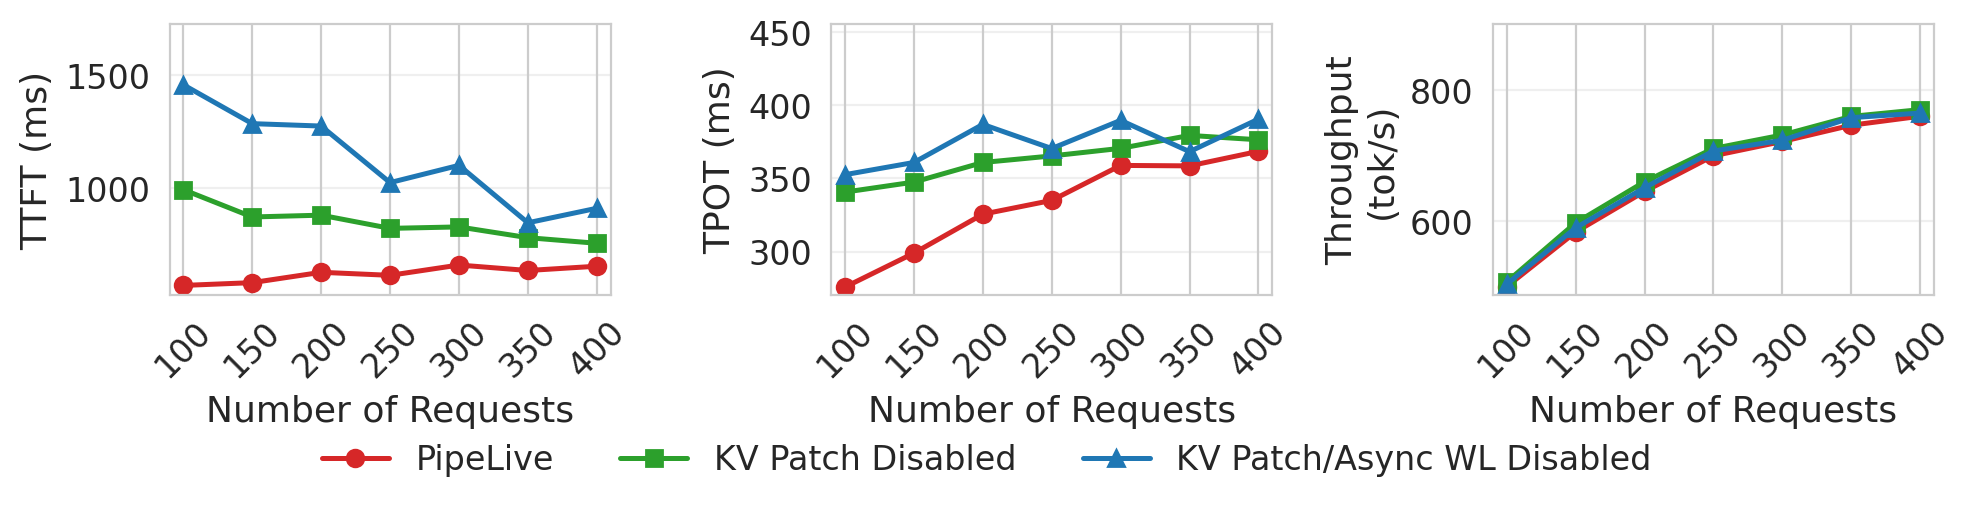


不同 n_requests 下的数据汇总（全部直接来自 benchmark.log 平均值）:
Mode                           n_req    TTFT(ms)     TrueNorm(ms/tok)   TPOT(ms/tok)     TotalThru(tok/s)   OutThru(tok/s)   ReqThru(req/s)  
----------------------------------------------------------------------------------------------------------------------------------------------------------------
PipeLive                       100           570.2           275.71         267.08            500.0          169.7           1.04
PipeLive                       150           582.6           298.93         289.68            583.3          199.7           1.20
PipeLive                       200           628.2           325.56         313.90            645.2          215.2           1.35
PipeLive                       250           614.9           334.98         323.00            699.7          239.6           1.44
PipeLive                       300           660.3           358.90         345.58            721.5          239.5           1.5

In [8]:
# 不同 n_requests 下的 Migration Mode 对比：直接从 benchmark.log 提取平均指标
# 数据来源: project-async-fast_duration

import re
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams['figure.dpi'] = 200

# ==================== 字体大小配置 ====================
FONT_SIZE_TICK = 12       # 刻度标签字体大小
FONT_SIZE_LABEL = 13      # 坐标轴标签字体大小
FONT_SIZE_LEGEND = 12     # 图例字体大小
# =====================================================

logs_dir_nreq = Path("/home/bxb1/vllm_workbench/vllm/new-logs/project-async-fast_duration_2")
print(f"日志目录: {logs_dir_nreq}")

def extract_params_nreq(dirname):
    """从目录名中提取 mig_mode 和 n_req"""
    params = {}

    mig_mode_match = re.search(r'\{mig_mode=([^}]+)\}', dirname)
    if mig_mode_match:
        params['mig_mode'] = mig_mode_match.group(1)

    nreq_match = re.search(r'\{n_req=(\d+)\}', dirname)
    if nreq_match:
        params['n_req'] = int(nreq_match.group(1))

    rr_match = re.search(r'\{rr=([\d.]+)\}', dirname)
    if rr_match:
        params['rr'] = float(rr_match.group(1))

    return params

def extract_benchmark_aggregate_metrics(benchmark_log_file):
    """
    直接从 benchmark.log 的 AGGREGATE STATISTICS 区域提取平均值。
    返回的单位保持为日志中的单位：
      - ttft_ms: ms
      - true_normalized_latency_ms_tok: ms/tok
      - tpot_ms_tok: ms/tok
      - throughput_tokens_per_s: tok/s
      - output_throughput_tok_s: tok/s
      - request_throughput_req_s: req/s
    """
    try:
        with open(benchmark_log_file, 'r', errors='ignore') as f:
            content = f.read()

        metrics = {}

        patterns = {
            'request_throughput_req_s': r'REQUEST THROUGHPUT \(req/s\):\s+Average:\s+([\d.]+)',
            'output_throughput_tok_s': r'OUTPUT THROUGHPUT \(tokens/s\):\s+Average:\s+([\d.]+)',
            'throughput_tokens_per_s': r'TOTAL TOKEN THROUGHPUT \(tokens/s\):\s+Average:\s+([\d.]+)',
            'ttft_ms': r'MEAN TTFT ACROSS REPETITIONS \(ms\):\s+Average:\s+([\d.]+)',
            'tpot_ms_tok': r'MEAN TPOT ACROSS REPETITIONS \(ms\):\s+Average:\s+([\d.]+)',
            'mean_e2el_ms': r'MEAN E2EL ACROSS REPETITIONS \(ms\):\s+Average:\s+([\d.]+)',
            'true_normalized_latency_ms_tok': r'MEAN NORMALIZED LATENCY ACROSS REPETITIONS \(ms/tok\):\s+Average:\s+([\d.]+)',
        }

        for key, pattern in patterns.items():
            match = re.search(pattern, content, re.DOTALL)
            if match:
                metrics[key] = float(match.group(1))

        return metrics
    except Exception as e:
        print(f"Error parsing aggregate metrics from {benchmark_log_file}: {e}")
        return {}

test_dirs = sorted([d for d in logs_dir_nreq.iterdir() if d.is_dir() and d.name.startswith('test-')])
print(f"找到 {len(test_dirs)} 个测试目录")

nreq_data = []
for test_dir in test_dirs:
    params = extract_params_nreq(test_dir.name)
    benchmark_log_file = test_dir / "benchmark.log"

    if 'mig_mode' not in params or 'n_req' not in params:
        continue

    row = {**params}

    if benchmark_log_file.exists():
        row.update(extract_benchmark_aggregate_metrics(benchmark_log_file))

    nreq_data.append(row)

df_nreq = pd.DataFrame(nreq_data)
print(f"成功处理 {len(df_nreq)} 个测试")

if df_nreq.empty:
    raise ValueError(f"未在 {logs_dir_nreq} 中解析到有效数据")

n_request_values = sorted(df_nreq['n_req'].dropna().unique())
mig_modes = ['async', 'async_fast', 'sync']

metrics_to_plot = [
    ('ttft_ms', 'TTFT (ms)', None),
    ('true_normalized_latency_ms_tok', 'TPOT (ms)', None),
    ('throughput_tokens_per_s', 'Throughput\n(tok/s)', None),
]

mode_labels = {'async': 'PipeLive', 'async_fast': 'KV Patch Disabled', 'sync': 'KV Patch/Async WL Disabled'}
colors  = {'async': '#D62728', 'async_fast': '#2CA02C', 'sync': '#1F77B4'}
markers = {'async': 'o', 'async_fast': 's', 'sync': '^'}

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(10, 2.2))

for col_idx, (metric_key, metric_label, y_max) in enumerate(metrics_to_plot):
    ax = axes[col_idx]

    for mode in mig_modes:
        mode_df = (
            df_nreq[df_nreq['mig_mode'] == mode]
            .sort_values('n_req')
            .dropna(subset=[metric_key])
        )

        if mode_df.empty:
            continue

        ax.plot(
            mode_df['n_req'],
            mode_df[metric_key],
            color=colors[mode],
            marker=markers[mode],
            linewidth=1.8,
            markersize=6,
            label=mode_labels[mode],
        )

    ax.set_xticks(n_request_values)
    ax.set_xticklabels([str(int(v)) for v in n_request_values], fontsize=FONT_SIZE_TICK, rotation=45)
    ax.set_xlabel('Number of Requests', fontsize=FONT_SIZE_LABEL)
    ax.set_ylabel(metric_label, fontsize=FONT_SIZE_LABEL)
    ax.tick_params(axis='y', labelsize=FONT_SIZE_TICK)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xlim(min(n_request_values) - 10, max(n_request_values) + 10)

    if y_max is not None:
        ax.set_ylim(top=y_max)
    else:
        ax.set_ylim(top=ax.get_ylim()[1] * 1.15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.2),
           ncol=len(mig_modes), fontsize=FONT_SIZE_LEGEND, frameon=False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.28)

out_pdf = '/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-migration-mode-nreq-true-norm-latency.pdf'
out_png = '/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-migration-mode-nreq-true-norm-latency.png'
plt.savefig(out_pdf, format='pdf', bbox_inches='tight')
plt.savefig(out_png, dpi=300, bbox_inches='tight')
print(f"已保存: {out_pdf}")
print(f"已保存: {out_png}")
plt.show()

print("\n" + "=" * 160)
print("不同 n_requests 下的数据汇总（全部直接来自 benchmark.log 平均值）:")
print("=" * 160)
print(f"{'Mode':<30} {'n_req':<8} {'TTFT(ms)':<12} {'TrueNorm(ms/tok)':<18} {'TPOT(ms/tok)':<16} {'TotalThru(tok/s)':<18} {'OutThru(tok/s)':<16} {'ReqThru(req/s)':<16}")
print("-" * 160)
for _, row in df_nreq.sort_values(['mig_mode', 'n_req']).iterrows():
    mode = row['mig_mode']
    n_req = row['n_req']
    ttft = row.get('ttft_ms', np.nan)
    true_norm_lat = row.get('true_normalized_latency_ms_tok', np.nan)
    tpot = row.get('tpot_ms_tok', np.nan)
    total_throughput = row.get('throughput_tokens_per_s', np.nan)
    out_throughput = row.get('output_throughput_tok_s', np.nan)
    req_throughput = row.get('request_throughput_req_s', np.nan)
    print(f"{mode_labels.get(mode, mode):<30} {n_req:<8} {ttft:>10.1f}   {true_norm_lat:>14.2f}   {tpot:>12.2f}   {total_throughput:>14.1f}   {out_throughput:>12.1f}   {req_throughput:>12.2f}")

In [10]:
# 诊断: 检查 layer 实验中 async stop time 是否遗漏了 forward lock
from pathlib import Path
import pandas as pd
import re


def extract_params_layer(dirname):
    """从目录名中提取参数，包括 migrated_layers"""
    params = extract_params_from_dirname(dirname)
    ml_match = re.search(r'\{migrated_layers=(\d+)\}', dirname)
    if ml_match:
        params['migrated_layers'] = int(ml_match.group(1))
    # 兼容其他可能的命名
    chunk_match = re.search(r'\{chunk=(\d+)\}', dirname)
    if chunk_match:
        params['migrated_layers'] = int(chunk_match.group(1))
    return params


diag_logs_dir = Path("/home/bxb1/vllm_workbench/vllm/new-logs/project-async-fast_stop_time_layer-3")
diag_rows = []

for test_dir in sorted([d for d in diag_logs_dir.iterdir() if d.is_dir() and 'mig_mode=async' in d.name and 'mig_mode=async_fast' not in d.name]):
    params = extract_params_layer(test_dir.name)
    analysis_file = test_dir / "analysis.txt"
    components = extract_stop_time_components(analysis_file, 'async')
    diag_rows.append({
        'migrated_layers': params.get('migrated_layers'),
        'engine_lock_ms': components['engine_lock_total'] * 1000,
        'forward_add_layers_ms': components['forward_lock_add_layers'] * 1000,
        'forward_compact_ms': components['forward_lock_compact'] * 1000,
        'forward_resize_shrink_ms': components['forward_lock_resize_shrink'] * 1000,
        'forward_resize_grow_ms': components['forward_lock_resize_grow'] * 1000,
        'forward_total_ms': components['forward_lock_total'] * 1000,
        'true_stop_time_ms': calculate_total_stop_time(components, 'async') * 1000,
    })

diag_df = pd.DataFrame(diag_rows).sort_values('migrated_layers')
print(diag_df.to_string(index=False))

 migrated_layers  engine_lock_ms  forward_add_layers_ms  forward_compact_ms  forward_resize_shrink_ms  forward_resize_grow_ms  forward_total_ms  true_stop_time_ms
               5            0.30                  1.230                 0.0                       0.0                    7.25             8.480              8.780
               5            0.28                  0.864                 0.0                       0.0                    8.79             9.654              9.934
               5            0.29                  1.090                 0.0                       0.0                    8.87             9.960             10.250
               5            0.26                  1.160                 0.0                       0.0                   26.61            27.770             28.030
